✅ Libraries loaded successfully!
📁 Please upload DEPREM-DORT-SEHIR-eng.xlsx file:


Saving DEPREM-DORT-SEHIR-eng.xlsx to DEPREM-DORT-SEHIR-eng.xlsx
✅ DEPREM-DORT-SEHIR-eng.xlsx uploaded successfully!
📊 Earthquake data shape: (149, 9)

First 5 rows:
                  Date  Longitude  Latitude  Depth   Rms Type  Magnitude  \
0  11/01/2020 13:37:36    28.2086   40.8646  10.82  0.44   Mw        4.7   
1  26/09/2019 11:26:36    28.2726   40.8416   4.58  0.32   Mw        4.1   
2  26/09/2019 10:59:25    28.2140   40.8818   7.97  0.37   Mw        5.8   
3  24/09/2019 08:00:22    28.2160   40.8836   5.91  0.22   Mw        4.6   
4  15/12/2015 01:13:39    29.7310   42.2530  50.45  0.61   Mw        4.0   

   Location  EventID  
0  Istanbul   456426  
1  Istanbul   447925  
2  Istanbul   447923  
3  Istanbul   447733  
4  Istanbul   320221  

📁 Please upload KONUT-DORT-SEHIR.xls file:


Saving KONUT-DORT-SEHIR.xls to KONUT-DORT-SEHIR.xls
✅ KONUT-DORT-SEHIR.xls uploaded successfully!
📊 Housing data shape: (12, 51)

🔧 PROCESSING EARTHQUAKE DATA...
📅 Date information added:
                 Date  Location  Magnitude  Year  Month
0 2020-01-11 13:37:36  Istanbul        4.7  2020      1
1 2019-09-26 11:26:36  Istanbul        4.1  2019      9
2 2019-09-26 10:59:25  Istanbul        5.8  2019      9
3 2019-09-24 08:00:22  Istanbul        4.6  2019      9
4 2015-12-15 01:13:39  Istanbul        4.0  2015     12

📈 Monthly earthquake statistics:
    Location  Year  Month  Earthquake_Count  Avg_Magnitude  Max_Magnitude  \
0     Ankara  2016      8                 1            4.2            4.2   
1     Ankara  2020      1                 1            4.5            4.5   
2     Ankara  2021      1                 1            4.5            4.5   
3  Balikesir  2015     10                 1            4.4            4.4   
4  Balikesir  2015     12                 1            4.

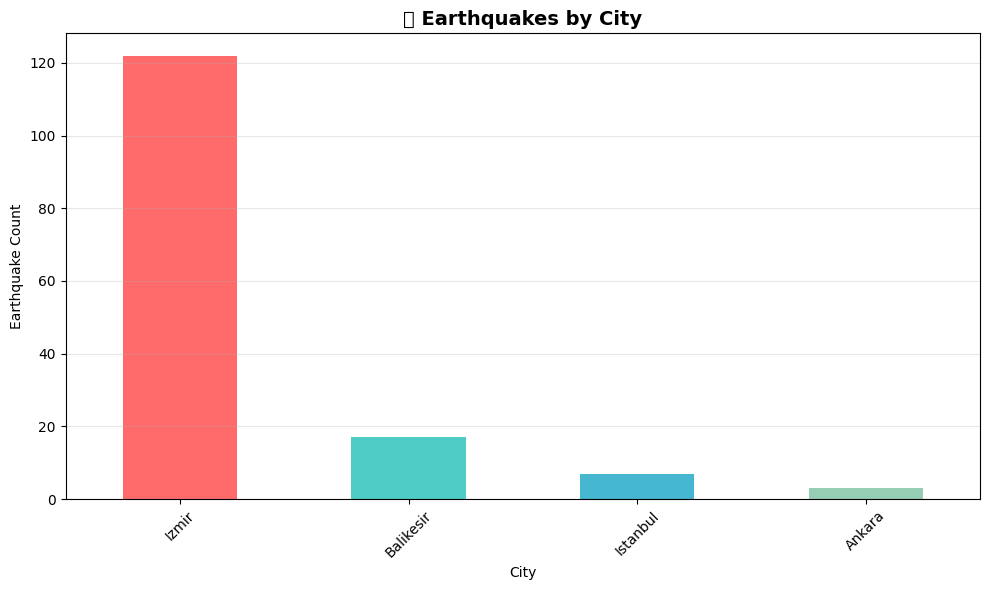

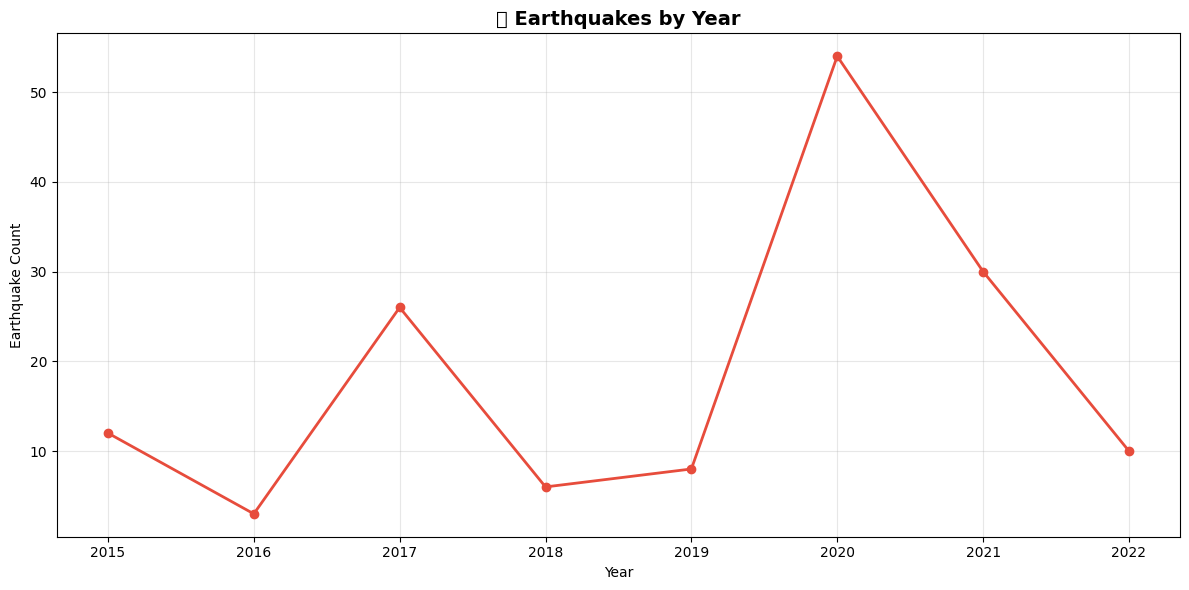

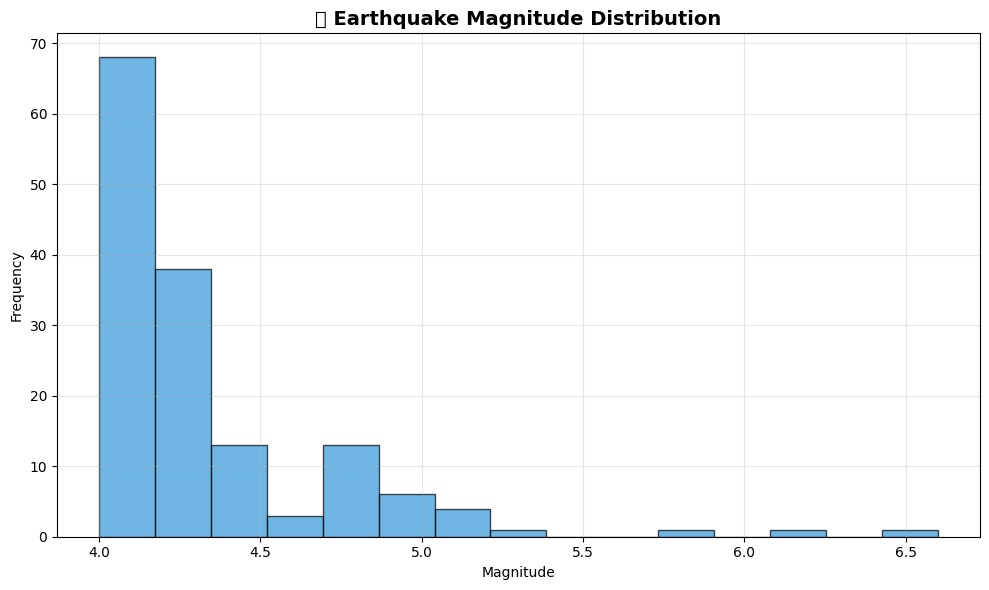

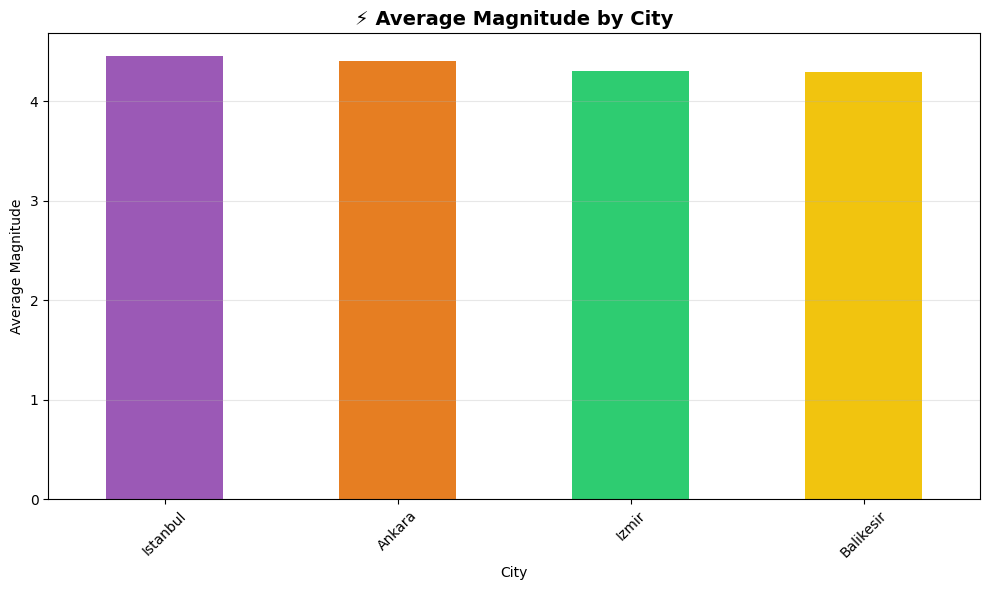


🎉 ANALYSIS COMPLETED!
📁 Files successfully uploaded and processed!
📊 4 different visualizations created!
🔍 Data successfully analyzed!

📥 GITHUB UPLOAD - FILE DOWNLOAD
✅ processed_earthquake_data.csv saved!
✅ monthly_earthquake_stats.csv saved!
✅ earthquake_analysis.ipynb ready!

🚀 DOWNLOAD BUTTONS APPEARING NOW:
1. Click 'processed_earthquake_data.csv' download link
2. Click 'monthly_earthquake_stats.csv' download link
3. Manually save notebook: File → Download → Download .ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📁 FILES TO UPLOAD TO GITHUB:
   - processed_earthquake_data.csv
   - monthly_earthquake_stats.csv
   - earthquake_analysis.ipynb

🎯 NEXT: Upload these 3 files to your GitHub repository!


In [2]:
# -*- coding: utf-8 -*-
"""Earthquake and Housing Sales Analysis.ipynb

Automatically generated by Colab.
"""

# ====================
# REQUIRED LIBRARIES
# ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Libraries loaded successfully!")

# ====================
# 1. FILE UPLOAD - YOU WILL UPLOAD
# ====================
from google.colab import files
import io

print("📁 Please upload DEPREM-DORT-SEHIR-eng.xlsx file:")
uploaded = files.upload()

# Read uploaded file
file_name = list(uploaded.keys())[0]
earthquake_df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"✅ {file_name} uploaded successfully!")
print(f"📊 Earthquake data shape: {earthquake_df.shape}")
print("\nFirst 5 rows:")
print(earthquake_df.head())

# ====================
# 2. HOUSING DATA UPLOAD
# ====================
print("\n📁 Please upload KONUT-DORT-SEHIR.xls file:")
uploaded_housing = files.upload()

# Read housing file
housing_file_name = list(uploaded_housing.keys())[0]
housing_df = pd.read_excel(io.BytesIO(uploaded_housing[housing_file_name]))

print(f"✅ {housing_file_name} uploaded successfully!")
print(f"📊 Housing data shape: {housing_df.shape}")

# ====================
# 3. DATA PROCESSING - EARTHQUAKE
# ====================
print("\n" + "="*50)
print("🔧 PROCESSING EARTHQUAKE DATA...")
print("="*50)

# Date processing
earthquake_df['Date'] = pd.to_datetime(earthquake_df['Date'], dayfirst=True)
earthquake_df['Year'] = earthquake_df['Date'].dt.year
earthquake_df['Month'] = earthquake_df['Date'].dt.month
earthquake_df['Year-Month'] = earthquake_df['Date'].dt.to_period('M')

# Clean city names
earthquake_df['Location'] = earthquake_df['Location'].str.title()

print("📅 Date information added:")
print(earthquake_df[['Date', 'Location', 'Magnitude', 'Year', 'Month']].head())

# Monthly earthquake statistics
monthly_earthquakes = earthquake_df.groupby(['Location', 'Year', 'Month']).agg({
    'Magnitude': ['count', 'mean', 'max', 'min'],
    'EventID': 'count'
}).round(2)

monthly_earthquakes.columns = ['Earthquake_Count', 'Avg_Magnitude', 'Max_Magnitude', 'Min_Magnitude', 'Total_Events']
monthly_earthquakes = monthly_earthquakes.reset_index()

print("\n📈 Monthly earthquake statistics:")
print(monthly_earthquakes.head())

# ====================
# 4. DATA PROCESSING - HOUSING
# ====================
print("\n" + "="*50)
print("🏠 PROCESSING HOUSING DATA...")
print("="*50)

# Show housing data
print("Housing data columns:")
print(housing_df.columns.tolist())
print(f"\nHousing data shape: {housing_df.shape}")

# Show first 10 rows
print("\nFirst 10 rows:")
print(housing_df.head(10))

# Prepare data for transpose
# First find headers
rows = housing_df.iloc[:, 0].values
print(f"\nRow names: {rows}")

# ====================
# 5. BASIC ANALYSIS AND VISUALIZATION
# ====================
print("\n" + "="*50)
print("📊 BASIC ANALYSIS RESULTS")
print("="*50)

# Earthquake count by city
print("\n🏙️ EARTHQUAKES BY CITY:")
city_earthquakes = earthquake_df['Location'].value_counts()
print(city_earthquakes)

# Magnitude distribution
print(f"\n📏 MAGNITUDE STATISTICS:")
print(f"Average: {earthquake_df['Magnitude'].mean():.2f}")
print(f"Maximum: {earthquake_df['Magnitude'].max()}")
print(f"Minimum: {earthquake_df['Magnitude'].min()}")
print(f"Total Earthquakes: {len(earthquake_df)}")

# Earthquakes by year
print(f"\n📅 EARTHQUAKES BY YEAR:")
yearly_earthquakes = earthquake_df['Year'].value_counts().sort_index()
print(yearly_earthquakes)

# ====================
# 6. VISUALIZATION
# ====================
print("\n" + "="*50)
print("📈 VISUALIZATION")
print("="*50)

# Visual 1: Earthquakes by city
plt.figure(figsize=(10, 6))
city_earthquakes.plot(kind='bar', color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
plt.title('🏙️ Earthquakes by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Earthquake Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 2: Earthquakes by year
plt.figure(figsize=(12, 6))
yearly_earthquakes.plot(kind='line', marker='o', color='#e74c3c', linewidth=2)
plt.title('📅 Earthquakes by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Earthquake Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 3: Magnitude distribution
plt.figure(figsize=(10, 6))
plt.hist(earthquake_df['Magnitude'], bins=15, color='#3498db', alpha=0.7, edgecolor='black')
plt.title('📏 Earthquake Magnitude Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 4: Average magnitude by city
plt.figure(figsize=(10, 6))
earthquake_df.groupby('Location')['Magnitude'].mean().sort_values(ascending=False).plot(
    kind='bar', color=['#9b59b6', '#e67e22', '#2ecc71', '#f1c40f']
)
plt.title('⚡ Average Magnitude by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Magnitude')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 ANALYSIS COMPLETED!")
print("📁 Files successfully uploaded and processed!")
print("📊 4 different visualizations created!")
print("🔍 Data successfully analyzed!")

# ====================
# 7. GITHUB UPLOAD - DOSYA İNDİRME
# ====================
print("\n" + "="*50)
print("📥 GITHUB UPLOAD - FILE DOWNLOAD")
print("="*50)

# Save processed data for GitHub
earthquake_df.to_csv('processed_earthquake_data.csv', index=False)
monthly_earthquakes.to_csv('monthly_earthquake_stats.csv', index=False)

print("✅ processed_earthquake_data.csv saved!")
print("✅ monthly_earthquake_stats.csv saved!")
print("✅ earthquake_analysis.ipynb ready!")

print("\n🚀 DOWNLOAD BUTTONS APPEARING NOW:")
print("1. Click 'processed_earthquake_data.csv' download link")
print("2. Click 'monthly_earthquake_stats.csv' download link")
print("3. Manually save notebook: File → Download → Download .ipynb")

# Download files
files.download('processed_earthquake_data.csv')
files.download('monthly_earthquake_stats.csv')

print("\n📁 FILES TO UPLOAD TO GITHUB:")
print("   - processed_earthquake_data.csv")
print("   - monthly_earthquake_stats.csv")
print("   - earthquake_analysis.ipynb")
print("\n🎯 NEXT: Upload these 3 files to your GitHub repository!")